## 代码

github地址：[https://github.com/foxabbage/cv-hw](https://github.com/foxabbage/cv-hw)下目录hw2<br>
模型参数：task1<br>
[https://www.modelscope.cn/models/foxabbage/pet-resnet18-train](https://www.modelscope.cn/models/foxabbage/pet-resnet18-train), <br>
[https://www.modelscope.cn/models/foxabbage/pet-resnet18-posttrain](https://www.modelscope.cn/models/foxabbage/pet-resnet18-posttrain),<br>
[https://www.modelscope.cn/models/foxabbage/pet-resnet18-vit](https://www.modelscope.cn/models/foxabbage/pet-resnet18-vit)<br>
task2<br>
[https://www.modelscope.cn/models/foxabbage/yolov8-visdrone](https://www.modelscope.cn/models/foxabbage/yolov8-visdrone)<br>
task3<br>
[https://www.modelscope.cn/models/foxabbage/unet-pet](https://www.modelscope.cn/models/foxabbage/unet-pet)<br>


## 任务1

1. 模型: Resnet-18, vit_tiny_patch16_224

    - Resnet-18: 由conv(kernel=7), max-pooling, 8个resnet-block(kernel=3), average-pooling, linear层构成，共18层
    - vit_tiny_patch16_224: 由patch-embedding(kernel=16, stride=16), position-embedding(添加[CLS]token), 16个transformer-encoder, linear层(仅取[CLS]token的decoder结果进行变换)构成

2. 数据集: The Oxford-IIIT Pet Dataset, 数据集中共37类宠物，每一类有约200张图片。训练集及验证集包含3680张图片，测试集包含3669张图片。
3. 数据预处理: 将短边缩放到256保持宽高比后随机裁剪224*224，对于训练集，有50%概率随机翻转图片作为数据增强，验证集和测试集进行中心裁切。
4. 测试集与验证集划分: 使用The Oxford-IIIT Pet Dataset中的train-val部分作为测试集和验证集，随机抽取其中的20%作为验证集，其余作为训练集进行训练。

### 1&2

使用Resnet-18的预训练权重作为初始权重，将线性输出头替换并随机初始化。训练使用网格搜索学习率，早停策略，cosine学习率调度器，带权重衰减的SGD动量优化器以及交叉熵损失函数进行训练。参数设置如下：

In [ ]:
lr_base = [5e-5, 1e-4, 5e-4]
lr_head = [1e-3, 3e-3, 5e-3]
epochs = 30
batch_size = 32
seed = 42
weight_decay = 1e-4
loss_label_smoothing = 0.1
scheduler_eta_min = 1e-6
sgd_momentum = 0.9
early_stop_patience = 5

训练结果如下：<br>
![image.png](./task1/result_images/pretrain_t.png)<br>
以验证集上的准确率作为评价指标，选取最优模型。<br>
得到的最优模型参数为训练部分lr=5e-4，输出头部分lr=5e-3，在验证集上准确率为0.8668。<br>
观察到相比较于预训练部分的学习率参数，输出头部分需要更大的参数进行更新。<br>
测试集上的表现如下：

In [13]:
!python test_pretrain.py

Test set size: 3669 samples

Test Accuracy: 0.8858
Test Loss: 0.4782


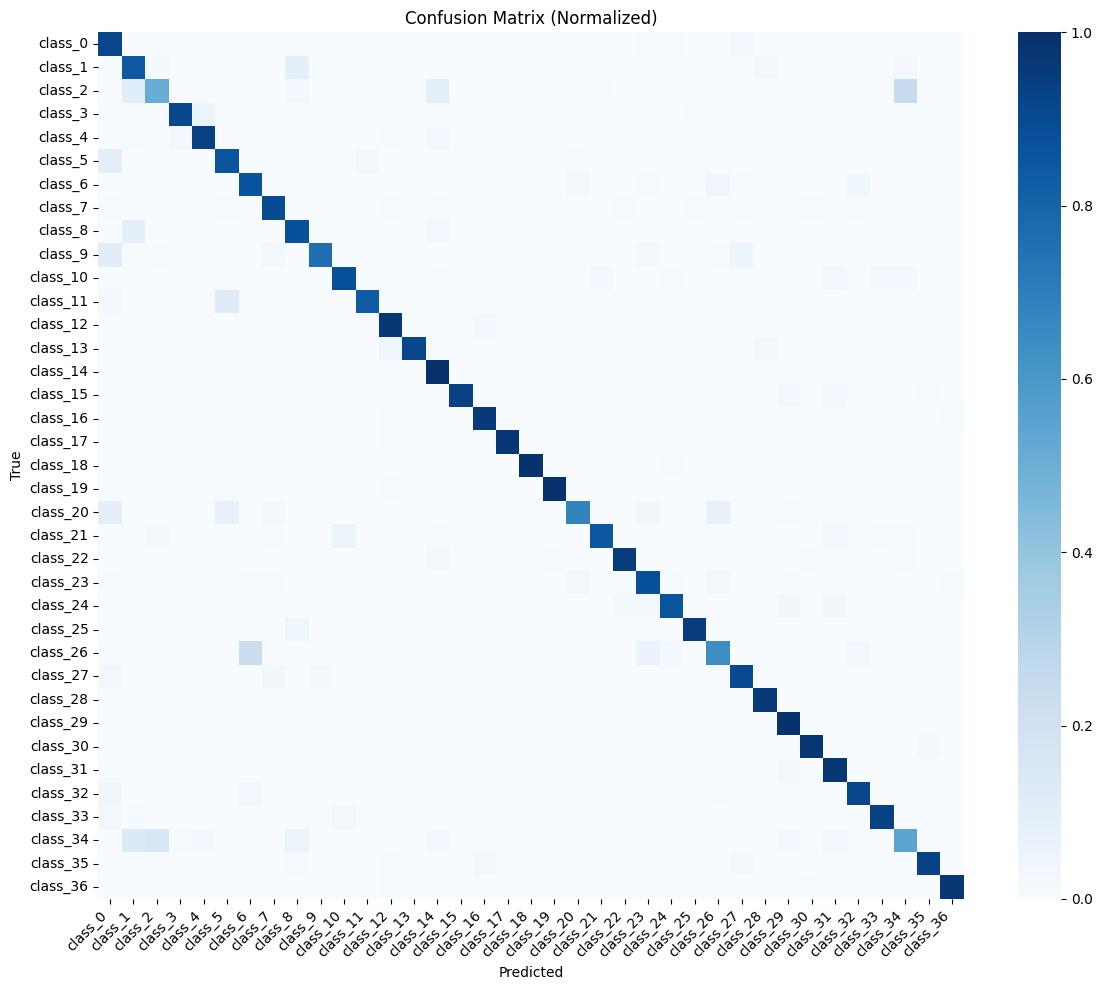

In [10]:
from IPython.display import Image
Image('./result_images/pretrain.jpg', width=600)

### 3

使用Resnet-18结构，随机初始化权重，将线性输出头替换并随机初始化。训练使用网格搜索学习率，早停策略，cosine学习率调度器，带权重衰减的SGD动量优化器以及交叉熵损失函数进行训练。参数设置如下：

In [ ]:
lr = [5e-2, 3e-2, 1e-2]
batch_size = 32
seed = 42
weight_decay = 1e-3
loss_label_smoothing = 0.1
scheduler_eta_min = 1e-6
sgd_momentum = 0.9
early_stop_patience = 10

此处先对lr=1e-3, 1e-2, 1e-1以及weight_decay=1e-4做了一次训练，观察到1e-3准确率低，1e-1无法训练，因此采用现在的lr列表，同时观察到weight_decay=1e-4时训练集准确率远远大于验证集准确率，有过拟合现象，因此加大了weight_decay重新训练。<br>
训练结果如下：<br>
![image.png](./task1/result_images/posttrain_t.png)<br>
最终得到的最优权重为lr=0.05，验证集上准确率为0.6888。<br>
可以看到相比于使用预训练权重得到的模型，从头训练得到的模型准确率大幅度下降，是由于使用的训练集远小于ImageNet，对于Resnet-18来说，使用的训练集数量规模较小，参数量远大于数据规模，使得模型过拟合，导致其在训练集上的表现远超验证集。而对于预训练参数，已经学习了大量数据，有提取图片特征的能力，只需要微调数据，使其更符合数据集就可以有较好的表现，不会使得噪声对于模型产生过大的影响，不易过拟合，因此表现更好。<br>
测试集上的表现如下：

In [14]:
!python test_posttrain.py

Test set size: 3669 samples

Test Accuracy: 0.7138
Test Loss: 1.1684


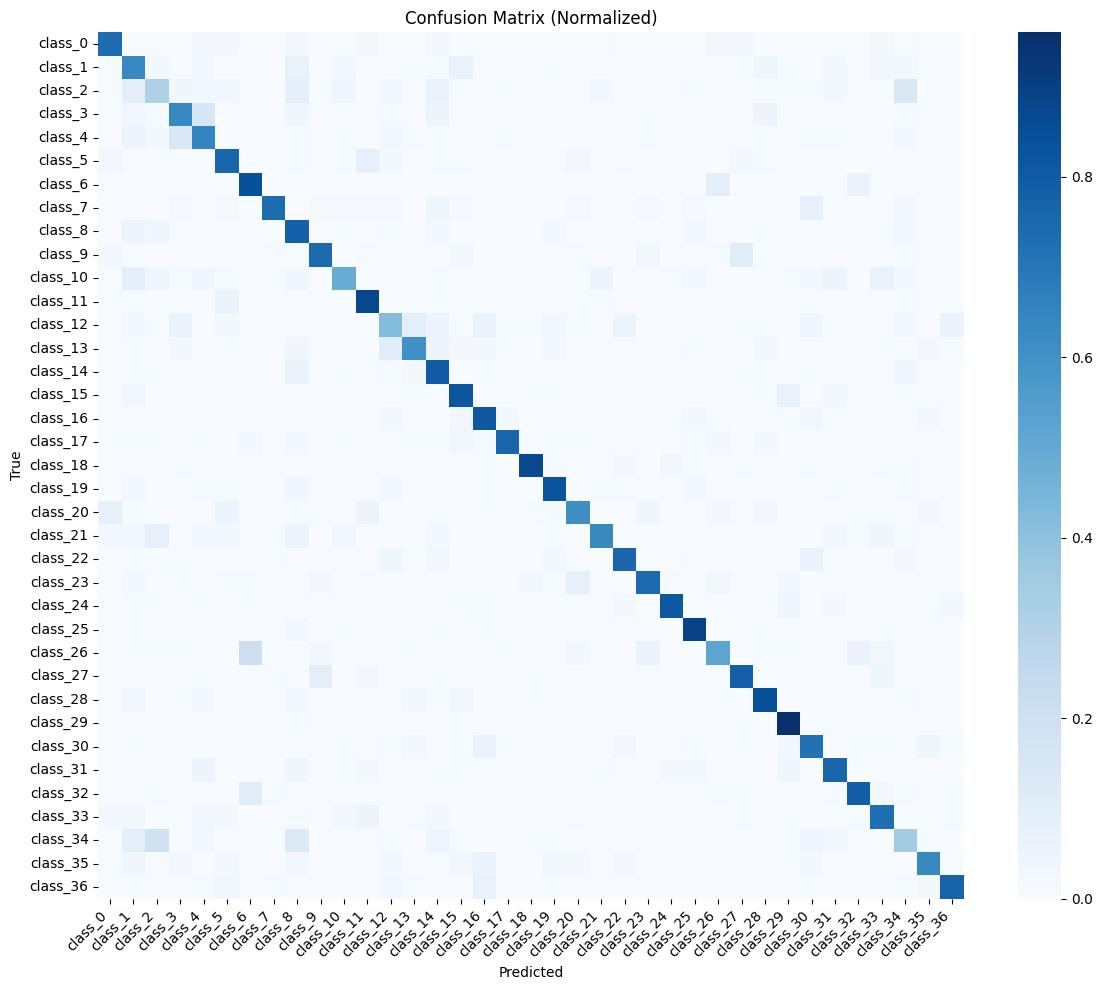

In [8]:
from IPython.display import Image
Image('./result_images/posttrain.jpg', width=600)

### 4

使用vit_tiny_patch16_224结构预训练权重，将线性输出头替换并随机初始化。训练使用网格搜索学习率，早停策略，cosine学习率调度器，带权重衰减的SGD动量优化器以及交叉熵损失函数进行训练。参数设置如下：

In [ ]:
lr_base = [1e-4, 5e-4, 1e-3]
lr_head = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
epochs = 30
batch_size = 32
seed = 42
weight_decay = 1e-4
loss_label_smoothing = 0.1
scheduler_eta_min = 1e-6
sgd_momentum = 0.9
early_stop_patience = 5

训练结果如下：<br>
![image.png](./task1/result_images/vit_t.png)<br>
最终得到的最优权重为训练部分lr=5e-4，输出头部分lr=5e-4，在验证集上准确率为0.8817。<br>
相比于baseline，在验证集上的准确率提升了约1.5%。<br>
测试集上的表现如下：

In [15]:
!python test_vit.py

Test set size: 3669 samples

Test Accuracy: 0.8937
Test Loss: 0.4819


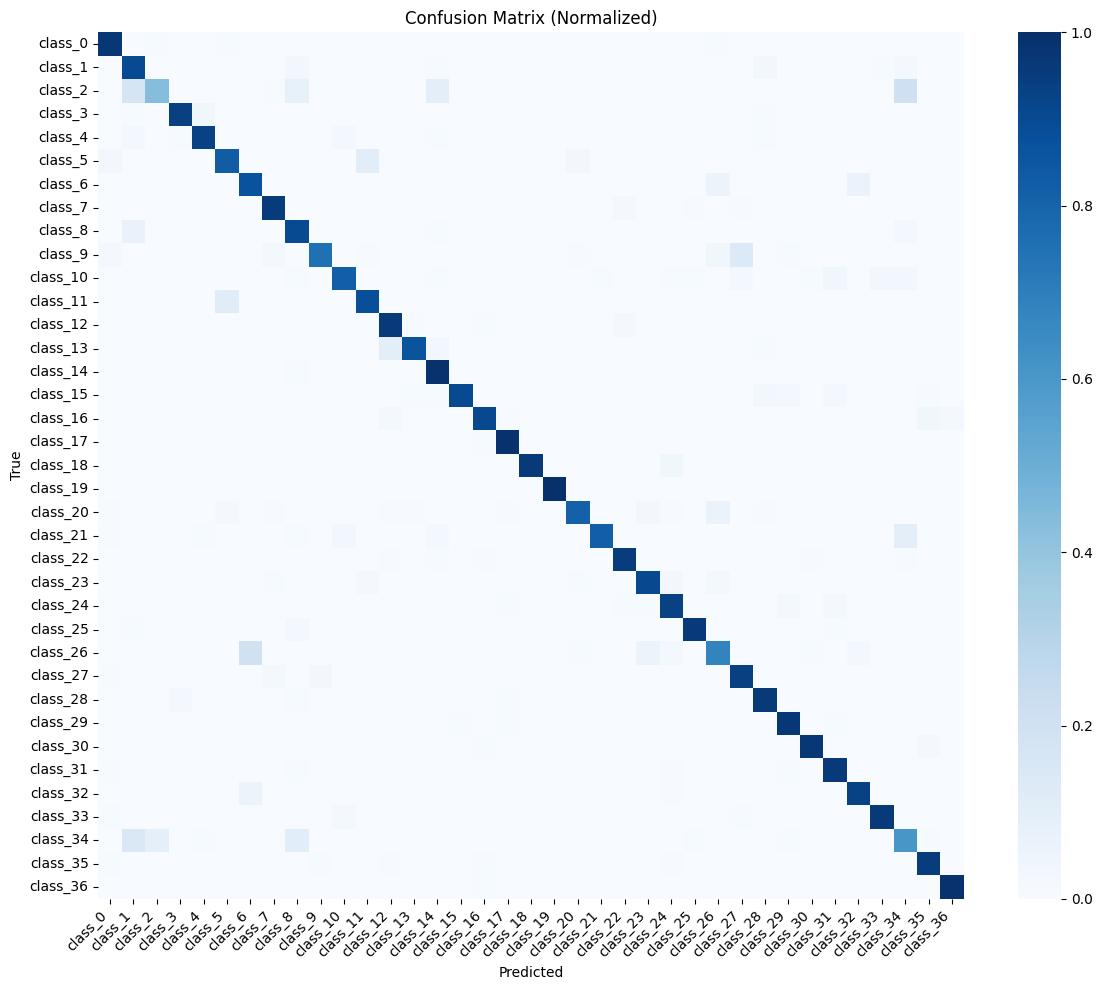

In [12]:
from IPython.display import Image
Image('./result_images/vit.jpg', width=600)

### 结果

在验证集与测试集上，以准确率作为评判指标，均有预训练vit>预训练Resnet-18>>随机初始化训练Resnet-18。

## 任务2

1. 数据集: VisDrone， 由 288 个视频片段（共 261,908 帧）和 10,209 张静态图像组成，包含 10 种物体。该数据集涵盖了广泛的应用场景，包括位置（中国 14 个不同城市）、环境（城市和乡村）、物体（行人、车辆、自行车等）以及密度（稀疏和拥挤场景）。数据集是在不同场景、天气和光照条件下，通过多种无人机平台采集的。这些帧经过人工标注，包含超过 260 万个目标边界框，如行人、汽车、自行车和三轮车等。
2. 数据预处理: 将目标边界框转换为yolo格式方便训练。
3. 模型：使用ultralytics中的YOLOv8

In [ ]:
yolo train \
  data=train.yaml \
  model=yolov8s.pt \
  epochs=100 \
  imgsz=800 \
  batch=16 \
  workers=0 \
  optimizer=AdamW \
  lr0=0.001 \
  lrf=0.01 \
  weight_decay=0.0005 \
  mosaic=0.0 \
  mixup=0.0 \
  copy_paste=0.0 \
  hsv_h=0.015 \
  hsv_s=0.7 \
  hsv_v=0.4 \
  degrees=0.0 \
  translate=0.1 \
  scale=0.5 \
  patience=30 \
  device=0 \
  project=runs/visdrone_yolov8s

训练结果：<br>
![image.png](./task2/train/results.png)<br>

### 遮挡分析

<table>
  <tr>
    <td><img src="./task2/visualization_frames_botsort/frame_0090.png" alt="frame_0090"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0091.png" alt="frame_0091"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0092.png" alt="frame_0092"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0093.png" alt="frame_0093"></td>
  </tr>
  <tr>
    <td><img src="./task2/visualization_frames_botsort/frame_0094.png" alt="frame_0094"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0095.png" alt="frame_0095"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0096.png" alt="frame_0096"></td>
    <td><img src="./task2/visualization_frames_botsort/frame_0097.png" alt="frame_0097"></td>
  </tr>
</table><br>

可以看到在物体(car, ID=23)被大范围遮挡后，发生了暂时性的目标丢失，原因在于物体的特征被遮盖，同时没有明显的边缘，导致预测边界框的置信度下降，从而导致目标的暂时性丢失。<br>
在重新出现后，车重新被识别，ID未改变，原因在于使用的追踪器BotSort具有特征提取和轨迹缓冲的能力，车的外观没有大幅度变化，同时运动近乎匀速，因此被识别为同一个ID；如果使用简单的追踪器(如IoU, SORT)，则会导致ID跳变，原因在于遮挡会直接导致检测框消失，没有重叠；多帧遮挡会导致运动轨迹的不确定性增大，无法持续跟踪，需要对特征进行保存或对轨迹进行预测才可以使ID不跳变。

### 越线计数

In [ ]:
!python count.py

总计跨越物体次数: 13
各类别跨越次数:
  truck: 1
  car: 5
  van: 1
  motor: 3
  people: 2
  bicycle: 1


计数跨越竖直的线x=200的物体<br>
![image.png](./task2/visualization_frames_botsort/frame_0071.png)<br>
由于设置的confidence阈值较高，因此会忽略较多的人行道对面的行人，此处对于车的统计较准确，但仍有缺漏，原因在于近处的自行车和人对车造成了遮挡，以及车刚进入画面时不完整，导致在线的某一侧没有被识别，因此无法被统计为跨越。

## 任务3

1. 数据集: The Oxford-IIIT Pet Dataset, 数据集中共37类宠物，每一类有约200张图片。训练集及验证集包含3680张图片，测试集包含3669张图片。
2. 数据预处理: 将短边缩放到256保持宽高比后随机裁剪224*224，对于训练集，有50%概率随机翻转图片作为数据增强，验证集和测试集进行中心裁切。
3. 测试集与验证集划分: 使用The Oxford-IIIT Pet Dataset中的train-val部分作为测试集和验证集，随机抽取其中的20%作为验证集，其余作为训练集进行训练。
4. 模型：4层Unet

    - basic block: 
        - UConv(in_ch, out_ch): [conv(3×3, padding=1, in_ch->out_ch), BN, ReLU], [conv(3×3, padding=1, out_ch->out_ch), BN, ReLU]
        - Upsample: (c, h, w) -> (c, 2h, 2w)
        - Upblock(in_ch, skip_ch, out_ch): Upsample+skip connection(concat)+UConv
    - network:

    ```mermaid
        graph TD
        Input["image"] --> UConv1["UConv(3, 64)"]

        UConv1 -->|"skip connection"| UpBlock1["Upblock(128, 64, 64)"]
        UConv1 --> MaxPool1["max_pooling(kernel=2, stride=2)"] --> UConv2["UConv(64, 128)"]

        UConv2 -->|"skip connection"| UpBlock2["Upblock(256, 128, 128)"]
        UConv2 --> MaxPool2["max_pooling(kernel=2, stride=2)"] --> UConv3["UConv(128, 256)"]

        UConv3 -->|"skip connection"| UpBlock3["Upblock(512, 256, 256)"]
        UConv3 --> MaxPool3["max_pooling(kernel=2, stride=2)"] --> UConv4["UConv(256, 512)"]

        UConv4 -->|"skip connection"| UpBlock4["Upblock(1024, 512, 512)"]
        UConv4 --> MaxPool4["max_pooling(kernel=2, stride=2)"] --> UConv5["UConv(512, 1024)"]

        UConv5 --> UpBlock4
        UpBlock4 --> UpBlock3 --> UpBlock2 --> UpBlock1

        UpBlock1 --> ConvOut["nn.Conv2d(64, out_ch, kernel_size=1)"] --> Output["output"]
    ```

5. 损失函数：

    - cross-entropy loss $\mathcal{L}_{\text{CE}} = -\frac{1}{N} \sum_{i=1}^{N} \log(p_{i, y_i})$
    - dice loss $\mathcal{L}_{\text{Dice}} = 1 - \frac{1}{C} \sum_{c=1}^{C} \frac{2\sum_{i} p_{c,i} \cdot t_{c,i} + \varepsilon}{\sum_i p_{c,i} + \sum_i t_{c,i} + \varepsilon}$
    - mixed loss 采用0.5, 0.5的权重混合dice loss和cross-entropy loss
    

使用早停策略，cosine学习率调度器，带权重衰减的SGD动量优化器采用如下的参数对三个不同的损失函数进行训练：

In [ ]:
lr = [1e-3, 1e-2]
batch_size = 16
seed = 42
weight_decay = 1e-3
loss_label_smoothing = 0.1
scheduler_eta_min = 1e-6
sgd_momentum = 0.9
early_stop_patience = 8

三个损失函数训练结果如下，依次为cross-entropy loss, dice loss, mixed loss：<br>

<table>
  <tr>
    <td><img src="./task3/results/ce.png" alt="ce"></td>
    <td><img src="./task3/results/dice.png" alt="dice"></td>
    <td><img src="./task3/results/mix.png" alt="mix"></td>
  </tr>
</table><br>

由于dice loss对应的训练图看起来未收敛，使用一个更大的epoch=130进行新训练。<br>
以mIoU作为评价指标，在验证集上三个损失函数最终的mIoU分别为0.7794, 0.7876, 0.7812<br>
在这个模型和训练集上dice loss的效果好于cross-entropy loss和mixed loss， mixed loss的验证集mIoU处于dice loss和cross-entropy loss中间。<br>

In [2]:
!python test.py --model_path ./models/ce.pth --loss ce

Loss             : 0.2622
Pixel Accuracy   : 0.9088
Mean IoU (mIoU)  : 0.7851
----------------------------------------
Per-Class IoU:
  Class 0 (Pixel belonging to the pet.) : 0.8807
  Class 1 (Pixel bordering the pet.) : 0.8860
  Class 2 (Background) : 0.5886


In [ ]:
!python test.py --model_path ./models/dice.pth --loss dice

Loss             : 0.1444
Pixel Accuracy   : 0.9112
Mean IoU (mIoU)  : 0.7899
----------------------------------------
Per-Class IoU:
  Class 0 (Pixel belonging to the pet.) : 0.8835
  Class 1 (Pixel bordering the pet.) : 0.8884
  Class 2 (Background) : 0.5978


In [4]:
!python test.py --model_path ./models/mix.pth --loss mix

Loss             : 0.2317
Pixel Accuracy   : 0.9103
Mean IoU (mIoU)  : 0.7868
----------------------------------------
Per-Class IoU:
  Class 0 (Pixel belonging to the pet.) : 0.8832
  Class 1 (Pixel bordering the pet.) : 0.8878
  Class 2 (Background) : 0.5893
